QUESTION 2
1. Write ADQL query for Gaia DR3.
2. Identify bad 2MASS photometry and non-positive Gaia parallax.
3. Produce 2-panel figure of Gaia BP-RP vs absG, and 2MASS J-Ks vs appH.
4. Observing Proposal Recommendation

In [2]:
#PART 1 --- ADQL Query 
from astroquery.gaia import Gaia
import os

#Defining the query --- what I'm specifically grabbing and from where.
query = """
SELECT
    gaia.source_id, gaia.ra, gaia.dec, gaia.parallax, gaia.pmra, gaia.pmdec, gaia.phot_g_mean_mag,
    gaia.bp_rp, tmass.designation AS tmass_designation, tmass.j_m, tmass.h_m, tmass.ks_m, tmass.ph_qual
FROM gaiadr3.gaia_source AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia.source_id = xmatch.source_id
JOIN gaiadr3.tmass_psc_xsc_join AS xjoin
    ON xmatch.clean_tmass_psc_xsc_oid = xjoin.clean_tmass_psc_xsc_oid
JOIN gaiadr1.tmass_original_valid AS tmass
    ON xjoin.original_psc_source_id = tmass.designation
WHERE 1 = CONTAINS(POINT('ICRS', gaia.ra, gaia.dec), CIRCLE('ICRS', 132.825, 11.8, 1.0))
    AND gaia.phot_g_mean_mag < 14
"""
#Lodge query (asynchronously, to avoid timeouts etc.)
job = Gaia.launch_job_async(query, dump_to_file=False)
M67data = job.get_results()

#Report the number of stars retrieved from the query.
print(f"Number of stars: {len(M67data)}")

#Write the results to a CSV file in the "data" directory, creating the directory if it doesn't exist.
os.makedirs("data", exist_ok=True)
M67data.write("data/M67data.csv", format="ascii.csv", overwrite=True)



INFO: Query finished. [astroquery.utils.tap.core]
Number of stars: 1018


In [13]:
#Part 2 --- Bad Data
import numpy as np

#Create mask for bad photometry.
bad_photometry_mask = M67data['ph_qual'] != 'AAA'
n_bad_photometry = bad_photometry_mask.sum()
print(f"Number of stars with bad photometry: {n_bad_photometry}")

#Create mask for bad parallax (parallax <= 0 or missing/masked out).
is_masked = M67data['parallax'].mask if hasattr(M67data['parallax'], 'mask') else False
bad_parallax_mask = (M67data['parallax'] <= 0) | np.isnan(M67data['parallax']) | is_masked
n_bad_parallax = np.ma.filled(bad_parallax_mask, fill_value=True).sum()
print(f"Number of stars with bad (non-positive or masked) parallax: {n_bad_parallax}")

#Filter the data and write to a new CSV file.
filtered_data = M67data[~bad_photometry_mask & ~bad_parallax_mask]
print(f"Number of stars with good data: {len(filtered_data)}")
filtered_data.write("data/M67data_filtered.csv", format="ascii.csv", overwrite=True)


Number of stars with bad photometry: 21
Number of stars with bad (non-positive or masked) parallax: 9
Number of stars with good data: 988


Figure successfully saved to figures/M67_CMDs.png


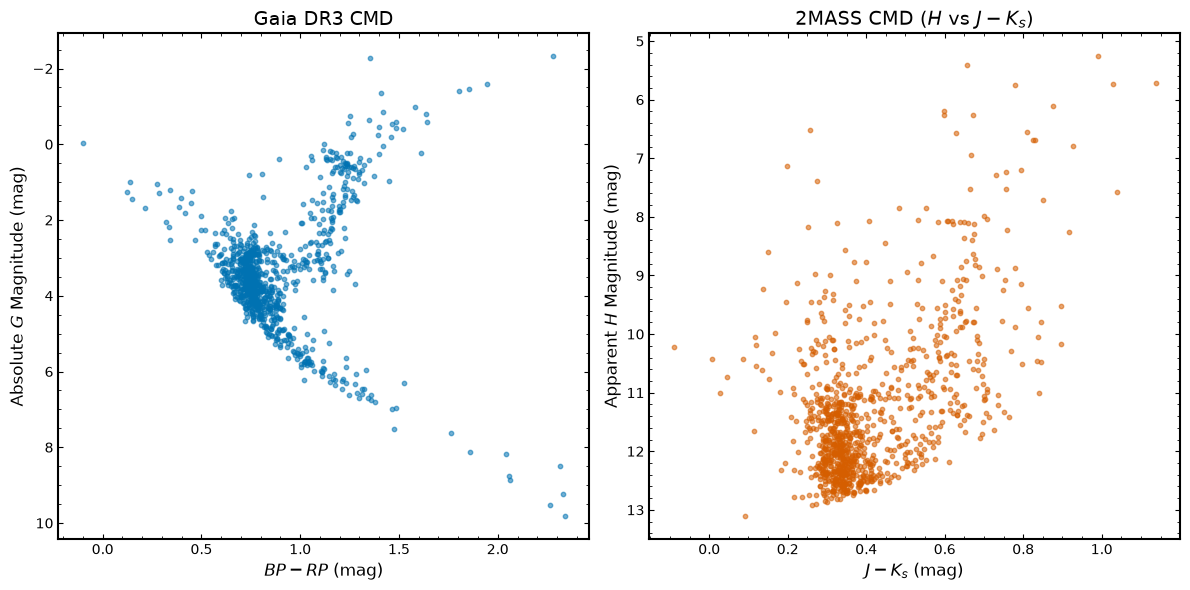

In [ ]:
#Part 3 --- It's plotting time!
import matplotlib.pyplot as plt

#Gaia --- Calculate abs G mag and colour.
g_mag_abs = filtered_data['phot_g_mean_mag'] + 5 * np.log10(filtered_data['parallax']) - 10
bp_rp = filtered_data['bp_rp']

#2MASS --- Calculate abs Ks mag and colour.
ks_mag_abs = filtered_data['ks_m'] + 5 * np.log10(filtered_data['parallax']) - 10
j_ks = filtered_data['j_m'] - filtered_data['ks_m']
h_mag = filtered_data['h_m']

#Some plotting aesthetics.
plt.rcParams.update({
    'font.family': 'sans-serif',
    'mathtext.fontset': 'dejavusans',
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

#Create a figure with two subplots.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Gaia DR3 CMD
gaia_colour = '#0072b2' #Colour-blind friendly.
axes[0].scatter(bp_rp, g_mag_abs, s=10, color=gaia_colour, alpha=0.55)
axes[0].invert_yaxis()
axes[0].set_xlabel(r'$BP - RP$ (mag)', fontsize=12)
axes[0].set_ylabel(r'Absolute $G$ Magnitude (mag)', fontsize=12)
axes[0].set_title('Gaia DR3 CMD', fontsize=14)
#axes[0].grid(True, linestyle='--', alpha=0.3) Decided against having a grid, think it looks better for a CMD.
axes[0].minorticks_on()

#2MASS CMD
tmass_colour = '#d55e00' #Colour-blind friendly.
axes[1].scatter(j_ks, h_mag, s=10, color=tmass_colour, alpha=0.55)
axes[1].invert_yaxis()
axes[1].set_xlabel(r'$J - K_s$ (mag)', fontsize=12)
axes[1].set_ylabel(r'Apparent $H$ Magnitude (mag)', fontsize=12)
axes[1].set_title('2MASS CMD ($H$ vs $J - K_s$)', fontsize=14)
#axes[1].grid(True, linestyle='--', alpha=0.3) Decided against having a grid, think it looks better for a CMD.
axes[1].minorticks_on()

plt.tight_layout()

os.makedirs("figures", exist_ok=True)
output_path = "figures/M67_CMDs.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure successfully saved to {output_path}")

plt.show()


Part 4 --- Observing Proposal Recommendation

I would not recommend this particular field for observation on this particular instrument.

Any 2dF/HERMES proposal must consider the physical limitations of the apparatus, no matter how technically sound the science is. This sample has 988 stars fit for observation, more than enough to justify the use of the instrument itself as it offers ample (~2.7x) target saturation for the operational fibres (~360), and the queried data radius matches the diameter of the 2dF instrument exactly. However, M67 is an open star cluster and as such all of the stars will be located rather centrally, and with very little separation. It so follows that the fibres will, given a small enough separation between observation targets (~40 arcsec), bump into each other. You could avoid this by placing the fibres further out, where the stars are spaced appropriately for this instrument, however at that point you would be missing most of the target data (which resides in the centre). Therefore, any observations made on this field using the 2dF/HERMES instrument, would necessitate multiple observation blocks --- a cost that simply cannot be justified.